# 04 — Project Report

This notebook summarises the full project — what we did, what we found, 
and what it means. It is written to be read independently of the 
other notebooks.

**Project:** Feature selection and predictive modelling of global life expectancy  
**Data:** WHO Global Health Observatory — 193 countries, 2000–2015  
**Author:** Lara Wahbi  
**LinkedIn:** linkedin.com/in/laraamro/

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Load all outputs from previous notebooks
df_clean = pd.read_csv('../data/life_expectancy_clean.csv')
df_selected = pd.read_csv('../data/selected_features.csv')
feature_selection = pd.read_csv('../data/feature_selection_results.csv')
model_results = pd.read_csv('../data/model_comparison_results.csv')
importance_df = pd.read_csv('../data/feature_importance.csv')
predictions_df = pd.read_csv('../data/model_predictions.csv')

print("All data loaded successfully")
print(f"Clean dataset: {df_clean.shape}")
print(f"Model results: {model_results.shape}")
print(f"Predictions: {predictions_df.shape}")

All data loaded successfully
Clean dataset: (2928, 18)
Model results: (4, 7)
Predictions: (586, 7)


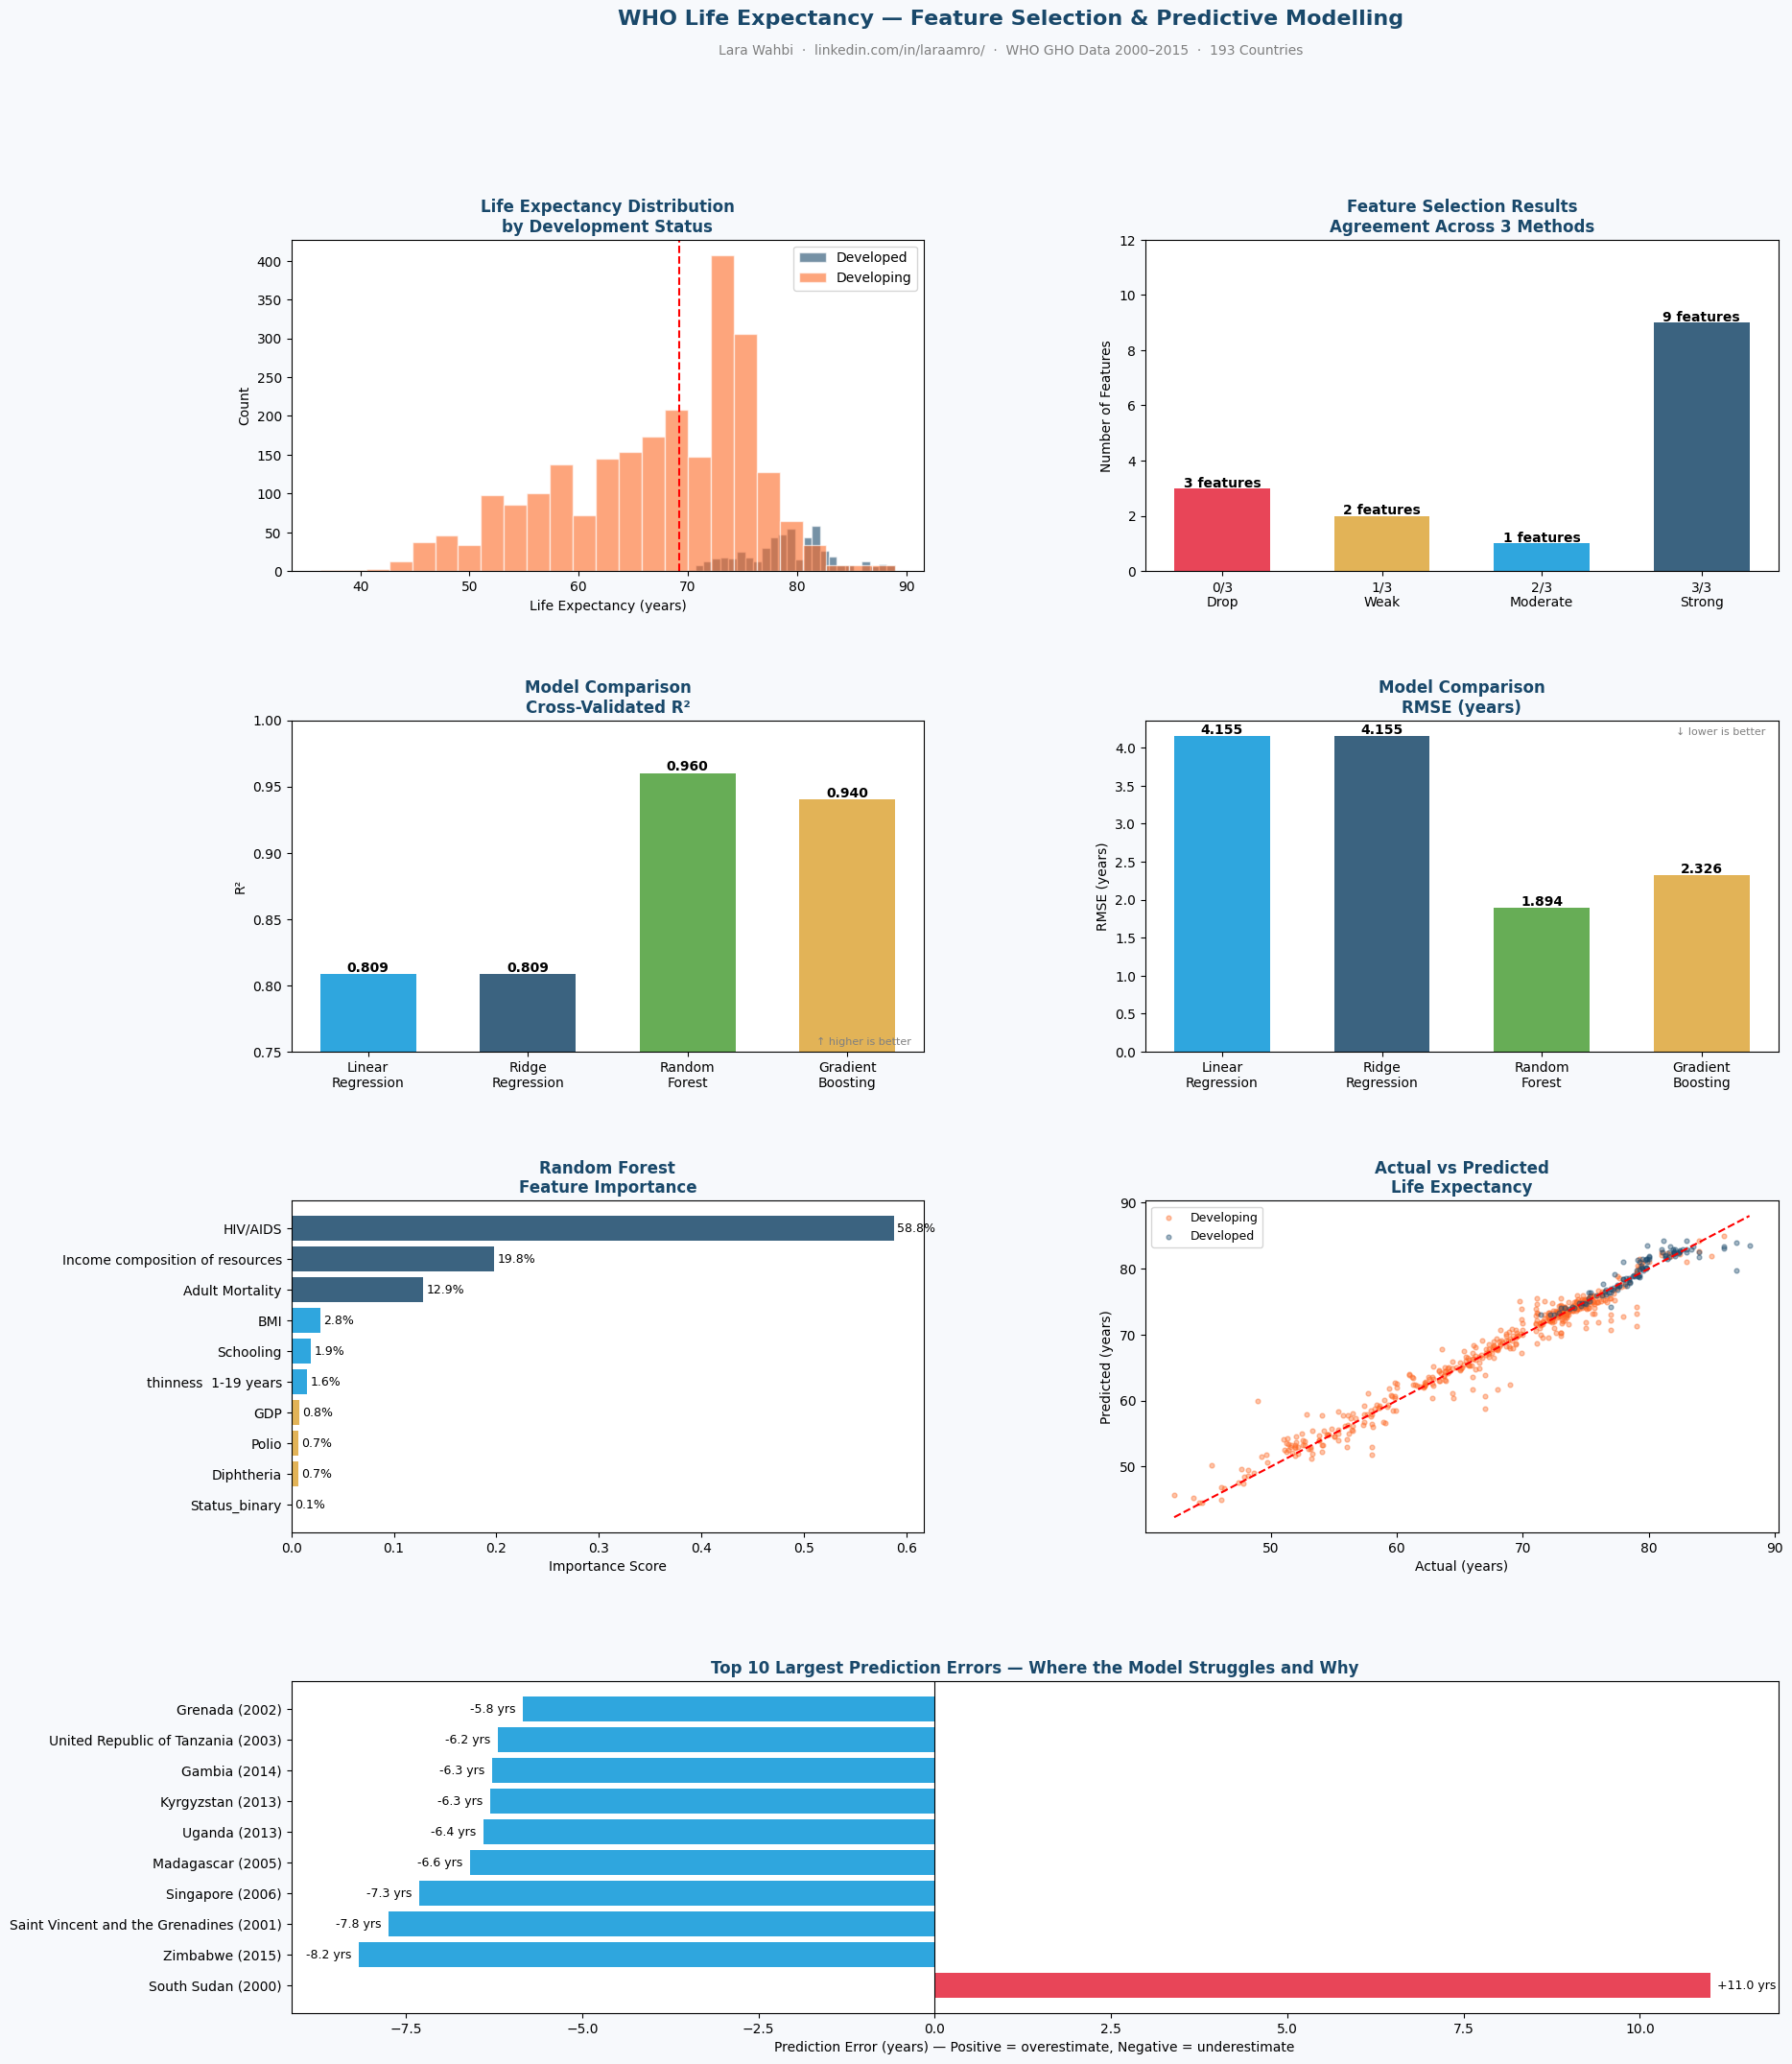

Dashboard saved


In [4]:
# ── SUMMARY DASHBOARD ─────────────────────────────────────────────
fig = plt.figure(figsize=(20, 24))
fig.patch.set_facecolor('#F7F9FC')

gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.35)

# SDG colour palette
NAVY   = '#19486A'
BLUE   = '#0A97D9'
GREEN  = '#4C9F38'
ORANGE = '#FD6925'
RED    = '#E5243B'
GOLD   = '#DDA63A'
PURPLE = '#8F1838'

# ── Panel 1: Life expectancy distribution by status ────────────────
ax1 = fig.add_subplot(gs[0, 0])
for status, color, label in [('Developed', NAVY, 'Developed'), 
                               ('Developing', ORANGE, 'Developing')]:
    data = df_clean[df_clean['Status'] == status]['Life expectancy']
    ax1.hist(data, bins=25, alpha=0.6, color=color, label=label, edgecolor='white')
ax1.set_title('Life Expectancy Distribution\nby Development Status', 
              fontweight='bold', color=NAVY)
ax1.set_xlabel('Life Expectancy (years)')
ax1.set_ylabel('Count')
ax1.legend()
ax1.axvline(df_clean['Life expectancy'].mean(), color='red', 
            linestyle='--', linewidth=1.5, label=f'Mean: {df_clean["Life expectancy"].mean():.1f}')

# ── Panel 2: Feature selection comparison ─────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
votes_count = feature_selection['Votes'].value_counts().sort_index()
colors_votes = [RED, GOLD, BLUE, NAVY]
bars = ax2.bar(
    ['0/3\nDrop', '1/3\nWeak', '2/3\nModerate', '3/3\nStrong'],
    [votes_count.get(i, 0) for i in range(4)],
    color=colors_votes, alpha=0.85, width=0.6
)
for bar, val in zip(bars, [votes_count.get(i, 0) for i in range(4)]):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.05,
             f'{val} features', ha='center', fontsize=10, fontweight='bold')
ax2.set_title('Feature Selection Results\nAgreement Across 3 Methods',
              fontweight='bold', color=NAVY)
ax2.set_ylabel('Number of Features')
ax2.set_ylim(0, 12)

# ── Panel 3: Model comparison R² ──────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
model_colors = [BLUE, NAVY, GREEN, GOLD]
bars = ax3.bar(
    model_results['Model'].str.replace(' ', '\n'),
    model_results['R²'],
    color=model_colors, alpha=0.85, width=0.6
)
ax3.set_ylim(0.75, 1.0)
ax3.set_title('Model Comparison\nCross-Validated R²',
              fontweight='bold', color=NAVY)
ax3.set_ylabel('R²')
for bar, val in zip(bars, model_results['R²']):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.002,
             f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
ax3.text(0.98, 0.02, '↑ higher is better', transform=ax3.transAxes,
         ha='right', fontsize=8, color='grey')

# ── Panel 4: Model comparison RMSE ────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
bars = ax4.bar(
    model_results['Model'].str.replace(' ', '\n'),
    model_results['RMSE'],
    color=model_colors, alpha=0.85, width=0.6
)
ax4.set_title('Model Comparison\nRMSE (years)',
              fontweight='bold', color=NAVY)
ax4.set_ylabel('RMSE (years)')
for bar, val in zip(bars, model_results['RMSE']):
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.03,
             f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
ax4.text(0.98, 0.98, '↓ lower is better', transform=ax4.transAxes,
         ha='right', va='top', fontsize=8, color='grey')

# ── Panel 5: Feature importance ───────────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
imp_colors = [NAVY if i < 3 else BLUE if i < 6 else GOLD 
              for i in range(len(importance_df))]
bars = ax5.barh(
    importance_df['Feature'],
    importance_df['Importance'],
    color=imp_colors, alpha=0.85
)
ax5.invert_yaxis()
ax5.set_title('Random Forest\nFeature Importance',
              fontweight='bold', color=NAVY)
ax5.set_xlabel('Importance Score')
for bar, val in zip(bars, importance_df['Importance']):
    ax5.text(val + 0.003, bar.get_y() + bar.get_height()/2,
             f'{val*100:.1f}%', va='center', fontsize=9)

# ── Panel 6: Actual vs Predicted ──────────────────────────────────
ax6 = fig.add_subplot(gs[2, 1])
dev_mask = predictions_df['Status'] == 'Developing'
ax6.scatter(predictions_df[dev_mask]['Actual'],
            predictions_df[dev_mask]['Predicted'],
            alpha=0.4, s=12, color=ORANGE, label='Developing')
ax6.scatter(predictions_df[~dev_mask]['Actual'],
            predictions_df[~dev_mask]['Predicted'],
            alpha=0.4, s=12, color=NAVY, label='Developed')
min_v = predictions_df['Actual'].min()
max_v = predictions_df['Actual'].max()
ax6.plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=1.5)
ax6.set_title('Actual vs Predicted\nLife Expectancy',
              fontweight='bold', color=NAVY)
ax6.set_xlabel('Actual (years)')
ax6.set_ylabel('Predicted (years)')
ax6.legend(fontsize=9)

# ── Panel 7: Top prediction errors ────────────────────────────────
ax7 = fig.add_subplot(gs[3, :])
top_errors = predictions_df.head(10).copy()
error_colors = [RED if e > 0 else BLUE for e in top_errors['Error']]
bars = ax7.barh(
    top_errors['Country'] + ' (' + top_errors['Year'].astype(str) + ')',
    top_errors['Error'],
    color=error_colors, alpha=0.85
)
ax7.axvline(x=0, color='black', linewidth=0.8)
ax7.set_title('Top 10 Largest Prediction Errors — Where the Model Struggles and Why',
              fontweight='bold', color=NAVY)
ax7.set_xlabel('Prediction Error (years) — Positive = overestimate, Negative = underestimate')
for bar, val in zip(bars, top_errors['Error']):
    ax7.text(val + (0.1 if val >= 0 else -0.1),
             bar.get_y() + bar.get_height()/2,
             f'{val:+.1f} yrs', va='center',
             ha='left' if val >= 0 else 'right', fontsize=9)

# ── SDG rainbow top bar ────────────────────────────────────────────
fig.text(0.5, 0.98,
         'WHO Life Expectancy — Feature Selection & Predictive Modelling',
         ha='center', va='top', fontsize=16, fontweight='bold', color=NAVY)
fig.text(0.5, 0.965,
         'Lara Wahbi  ·  linkedin.com/in/laraamro/  ·  WHO GHO Data 2000–2015  ·  193 Countries',
         ha='center', va='top', fontsize=10, color='grey')

plt.savefig('../outputs/04_summary_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='#F7F9FC')
plt.show()
print("Dashboard saved")

## Key Findings

### 1. Feature Selection
Three independent methods — correlation analysis, forward stepwise 
regression, and LASSO — were applied to 15 candidate variables. 
Nine variables reached unanimous agreement across all three methods:

- **HIV/AIDS, Income composition of resources, Adult Mortality** — 
  the three dominant predictors
- **BMI, Schooling, thinness 1–19 years, GDP, Polio, Diphtheria** — 
  confirmed secondary predictors

Three variables were unanimously dropped: infant deaths, Hepatitis B, 
and Total expenditure. Their information is already captured by 
stronger variables in the selected set.

### 2. Model Performance
Random Forest outperformed all other models:

| Model | R² | RMSE |
|---|---|---|
| Linear Regression | 0.809 | 4.16 years |
| Ridge Regression | 0.809 | 4.16 years |
| **Random Forest** | **0.960** | **1.89 years** |
| Gradient Boosting | 0.940 | 2.33 years |

The 15-point R² gap between linear and tree-based models confirms 
that life expectancy has significant non-linear relationships — 
the effect of HIV/AIDS is catastrophic above a threshold but 
near-zero below it, a pattern linear regression cannot capture.

### 3. What Actually Drives Life Expectancy
HIV/AIDS accounts for 58.8% of the Random Forest's predictive power — 
far exceeding its correlation ranking of 5th. This reveals a threshold 
effect invisible to correlation analysis: HIV/AIDS barely affects 
life expectancy in most countries but is catastrophic in a subset 
of sub-Saharan African nations. Income composition (19.8%) and 
Adult Mortality (12.9%) complete the dominant three, accounting 
for 91.5% of predictive power combined.

Schooling had the highest individual correlation (0.73) but ranked 
5th in feature importance (1.9%) — its information is largely 
captured by Income composition, with which it shares an 0.80 
correlation.

### 4. Where the Model Struggles
The 10 largest prediction errors cluster around three patterns:

- **Active conflict** — South Sudan 2000 (+11 years overestimate). 
  No variable in the dataset captures armed conflict or health 
  system collapse.
- **Rapid transitions** — Zimbabwe 2015 (–8.2 years). The model 
  learned Zimbabwe as a low life expectancy country during the 
  HIV/AIDS crisis; it underestimates the post-2010 recovery.
- **Outlier efficiency** — Singapore 2006 (–7.3 years). Exceptional 
  governance and healthcare efficiency produces outcomes beyond 
  what development indicators alone predict.

### 5. Limitations
- Data covers 2000–2015. Post-2015 dynamics including COVID-19 
  are not represented.
- Missing data concentrated in smaller, less-documented countries 
  was imputed using group medians — introducing uncertainty for 
  those observations.
- Random Forest feature importance can be unstable when correlated 
  predictors are present. The Schooling vs Income composition 
  result should be interpreted with this in mind.